# AI-агент для суммаризации и извлечения метрик из документов

В этом ноутбуке мы **пошагово** строим AI-агента на LangGraph, который умеет:
1. **Суммаризировать** PDF-документ — создавать краткое информативное резюме
2. **Извлекать метрики** — находить количественные, временные и качественные показатели

На каждом шаге мы добавляем новую способность или улучшаем архитектуру, демонстрируя ключевые паттерны построения агентов:

| Шаг | Что добавляем |
|-----|---------------|
| 1 | Базовая суммаризация — минимальный агент |
| 2 | Улучшенный промпт — промпт-инжиниринг |
| 3 | Извлечение метрик — второй навык агента |
| 4 | Улучшенный промпт для метрик |
| 5 | Map-Reduce + параллелизация |
| 6 | Парсинг изображений |
| 7 | Финальная архитектура — полный документ с изображениями |

## Документ для анализа
`input/1. Gartner_Top 10 Strategic Technology Trends_2026.pdf` — отчёт Gartner о 10 стратегических технологических трендах 2026 года (~40 страниц, содержит диаграммы, таблицы и прогнозы).

# Эталоны для сравнения

Перед началом работы определим эталонные результаты, с которыми будем сверяться на каждом шаге.

In [2]:
# Эталон суммаризации (NotebookLM) — для визуального сравнения
ETALON = (
    "Этот отчет компании Gartner представляет десять ключевых технологических стратегий, "
    "которые станут определяющими для бизнеса к 2026 году. Эксперты распределили актуальные "
    "направления по трём фундаментальным категориям: создание надёжной цифровой базы, интеграция "
    "интеллектуальных систем и укрепление информационной безопасности. Особое внимание уделяется "
    "переходу к узкоспециализированным языковым моделям, автономным системам ИИ и защищённым "
    "вычислительным средам. Документ содержит практические планы действий для руководителей, "
    "стремящихся адаптировать свои организации к условиям гиперподключённого мира. Авторы подчёркивают, "
    "что успех будет зависеть от способности компаний оперативно внедрять инновации, сохраняя при этом "
    "высокий уровень доверия и прозрачности в использовании данных. Таким образом, руководство служит "
    "дорожной картой для достижения долгосрочного конкурентного преимущества в эпоху тотальной "
    "цифровой трансформации."
)
print("Эталон суммаризации (NotebookLM):")
print(ETALON)

Эталон суммаризации (NotebookLM):
Этот отчет компании Gartner представляет десять ключевых технологических стратегий, которые станут определяющими для бизнеса к 2026 году. Эксперты распределили актуальные направления по трём фундаментальным категориям: создание надёжной цифровой базы, интеграция интеллектуальных систем и укрепление информационной безопасности. Особое внимание уделяется переходу к узкоспециализированным языковым моделям, автономным системам ИИ и защищённым вычислительным средам. Документ содержит практические планы действий для руководителей, стремящихся адаптировать свои организации к условиям гиперподключённого мира. Авторы подчёркивают, что успех будет зависеть от способности компаний оперативно внедрять инновации, сохраняя при этом высокий уровень доверия и прозрачности в использовании данных. Таким образом, руководство служит дорожной картой для достижения долгосрочного конкурентного преимущества в эпоху тотальной цифровой трансформации.


In [3]:
# Эталон метрик (NotebookLM) — промпт и результат для сравнения
prompt_notebook_lm = """Найди метрики (временные, количественные, качественные) в этом документе. Найденные метрики сгруппируй по призканам. Примеры признаков:
    связанные с кибер атаками
    связанные с защитой кибер периметра
    связанные с сетью
    связанные с системами
    связанные с бизнес процессами.
    Не обязательно придерживаться именно такой классификации. Используй ее как отправную точку и пример. Если поймешь, что метрики группируются по другим признакам, то можешь добавить новые признаки
"""

result_notebook_ml = """На основе предоставленного документа Gartner, ниже приведен перечень метрик (количественных, временных и качественных), сгруппированных по предложенным и дополнительным признакам.
1. Метрики, связанные с киберугрозами и атаками
В этой группе представлены количественные показатели масштаба угроз, с которыми столкнутся организации к 2030 году.
    Количество уязвимостей: Ожидается, что число задокументированных уязвимостей превысит 1 миллион ежегодно к 2030 году.
    Природа угроз ИИ: 80% несанкционированных транзакций ИИ будут связаны с внутренними нарушениями политик безопасности, а не с внешними атаками.
2. Метрики, связанные с защитой киберпериметра и безопасностью
Эти метрики отражают переход к новым методам защиты данных и инфраструктуры.
    Инвестиции в упреждающую защиту: К 2030 году 50% всех расходов на защитное ПО будет направлено на решения для упреждающей (preemptive) кибербезопасности.
    Защита данных в процессе обработки: К 2029 году 75% процессов обработки данных в недоверенной инфраструктуре будут защищены с помощью конфиденциальных вычислений.
    Внедрение платформ безопасности ИИ (AISP): Более 50% предприятий внедрят специализированные платформы безопасности ИИ к 2028 году.
    Рыночная релевантность: К 2029 году технологические продукты, не обладающие функциями упреждающей безопасности, потеряют актуальность на рынке.
3. Метрики, связанные с системами и инфраструктурой
Показатели трансформации вычислительных мощностей и способов размещения рабочих нагрузок.
    Гибридные вычисления: 40% предприятий перейдут на гибридные вычислительные архитектуры к 2028 году (значительный рост по сравнению с 8% в 2025 году).
    Рынок суперкомпьютеров ИИ: К 2028 году более 20 поставщиков предложат унифицированные платформы для разработчиков, использующие среды суперкомпьютерных вычислений.
    Геопатриация (локализация): К 2030 году 75% предприятий перенесут свои рабочие нагрузки из глобальных публичных облаков в суверенные или локальные среды («геопатриация»).
    Локальный ИИ: К 2028 году 30% рабочих нагрузок генеративного ИИ (GenAI) будут использовать отраслевые модели (DSLM), работающие локально или непосредственно на устройствах.
4. Метрики, связанные с разработкой ПО и кадрами
Метрики, описывающие качественные и количественные изменения в структуре команд и методах создания приложений.
    Эволюция команд: К 2030 году 80% организаций заменят крупные команды инженеров ПО на маленькие группы, усиленные ИИ («tiny teams»).
    Доля AI-native приложений: К 2030 году 40% портфеля корпоративных приложений будут составлять кастомные решения, созданные на AI-native платформах (в 2025 году этот показатель составляет всего 2%).
    Интерес к мультиагентным системам (MAS): Зафиксирован взрывной рост интереса — количество запросов по MAS увеличилось на 1445% в период с 1 кв. 2024 по 2 кв. 2025 года.
    Эффективность команд: Пример качественного изменения — возможность для 5 команд из 2 человек поставлять 5 приложений одновременно благодаря инструментам генеративного ИИ.
5. Метрики, связанные с бизнес-процессами и отраслевой спецификой
Показатели автоматизации физических и операционных процессов.
    Автоматизация складов: К 2028 году 80% складов будут использовать робототехнику или средства автоматизации.
    Отраслевая специализация ИИ: К 2028 году 50% всех корпоративных моделей GenAI будут узкоспециализированными (domain-specific), а не общими.
    Специализация ИИ-агентов: К 2027 году 70% мультиагентных систем будут состоять из узкоспециализированных агентов для повышения точности.
    Совместимость решений: К 2028 году 60% мультиагентных систем будут поддерживать работу с решениями от разных вендоров (multivendor interoperability)"""

print("Эталон метрик (NotebookLM):")
print(result_notebook_ml)

Эталон метрик (NotebookLM):
На основе предоставленного документа Gartner, ниже приведен перечень метрик (количественных, временных и качественных), сгруппированных по предложенным и дополнительным признакам.
1. Метрики, связанные с киберугрозами и атаками
В этой группе представлены количественные показатели масштаба угроз, с которыми столкнутся организации к 2030 году.
    Количество уязвимостей: Ожидается, что число задокументированных уязвимостей превысит 1 миллион ежегодно к 2030 году.
    Природа угроз ИИ: 80% несанкционированных транзакций ИИ будут связаны с внутренними нарушениями политик безопасности, а не с внешними атаками.
2. Метрики, связанные с защитой киберпериметра и безопасностью
Эти метрики отражают переход к новым методам защиты данных и инфраструктуры.
    Инвестиции в упреждающую защиту: К 2030 году 50% всех расходов на защитное ПО будет направлено на решения для упреждающей (preemptive) кибербезопасности.
    Защита данных в процессе обработки: К 2029 году 75% проце

# Импорты и настройка

In [4]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""

In [5]:
%load_ext autoreload
%autoreload 2

import operator
from typing import TypedDict, List, Dict, Any
from typing_extensions import Annotated

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langgraph.checkpoint.memory import MemorySaver

from langchain.messages import HumanMessage, SystemMessage
from langchain_gigachat.chat_models import GigaChat

from docling_core.types.doc import DoclingDocument

from dotenv import load_dotenv
from IPython.display import Image
from rich import print
import pandas as pd

from src.tools import parse_pdf_docling, make_parse_pdf_gigachat_postprocess
from src.utils import show_prompt

In [6]:
load_dotenv()
key = os.environ.get('GIGACHAT_API_KEY')

llm = GigaChat(
    credentials=key,
    model='GigaChat-2-Max',
    scope='GIGACHAT_API_CORP',
    temperature=0.87,
    verify_ssl_certs=False,
    profanity_check=False,
    max_tokens=25000,
    timeout=300,
)

# Промпты

Собираем все промпты в одном месте. По ходу ноутбука будем ссылаться на них по имени.

In [7]:
# === Промпты для суммаризации ===

# Шаг 1: минимальный промпт — даём модели максимум свободы
STEP1_SUMMARY_PROMPT = "Кратко суммаризируй следующий документ на русском языке. Объём: 5-10 предложений."

# Шаг 2: структурированный промпт с явными требованиями к содержанию
STEP2_SUMMARY_PROMPT = """Ты эксперт по технологическим трендам. Создай краткое, но информативное резюме отчёта на русском языке (5–7 предложений).

Резюме обязательно должно отражать:
1. Общую тему и цель отчётад, укажи компанию, год.
2. Опиши главные мысли и идеи.
3. Перечисли упоминаемые тренды, технологии, концепции и другие значимые артефакты из отчёта, если они есть (например: специализированные языковые модели, мультиагентные системы, конфиденциальные вычисления, геопатриация данных).
4. Упоминание практических планов, действий для руководителей.
5. Подытожь основной посыл

Пиши связным текстом без маркированных списков. Объём: 5–10 предложений."""

# === Промпты для извлечения метрик ===

# Шаг 3: базовый промпт метрик (тот же, что использовался в NotebookLM для честного сравнения)
# prompt_notebook_lm — определён выше

# Шаг 4+: улучшенный промпт метрик с ролью аналитика и строгим форматом
new_prompt = '''Ты специалист по кибербезопасности, который занимается профессиональной публицистикой и глубоким анализом аналитических отчетов \
в сфере кибербезопасности.
Проанализируй документ ниже и найди метрики (временные, количественные, качественные).
Метрики могут быть либо явно указаны в тексте документа, либо сформулированы тобой исходя описания возможных изменений \
(рост, снижение, изменение интенсивности чего-либо и т.д.). 
Метрики ОБЯЗАТЕЛЬНО должны выражаться какими-то числовыми значениями. \
Если есть какое-то описание метрики, но нет цифрового выражения, то эту метрику описывать не нужно. 
Для каждой метрики необходимо указать краткое емкое название и описание, что именно метрика показывает (исходное в тексте либо сформулированное тобой) \
в описании обязательно должно быть цифровое выражение этой метрики. 
Обрати внимание, что метрики могут быть временные, количественные, качественные. \
Необходимо найти и описать ВСЕ метрики, упомянутые в документе. В случае отсутствия метрик укажи "Отчет не содержит метрик". \
Если метрики найдены, сгруппируй по призканам. Примеры признаков:
    связанные с кибер атаками
    связанные с защитой кибер периметра
    связанные с сетью
    связанные с системами
    связанные с бизнес процессами.
Не обязательно придерживаться именно такой классификации. Используй ее как отправную точку и пример. \
Если поймешь, что метрики группируются по другим признакам, то можешь добавить новые признаки.
Формат вывода: нумерованный список групп метрик. В каждой групп ненумерованный список метрик, входящих в эту группу.
Формат вывода метрик: "Название метрики: Описание метрики вместе с числовыми показателями".
Пример: 
"1. Метрики, связанные с киберугрозами и атаками
    - Количество уязвимостей: Ожидается, что число задокументированных уязвимостей превысит 100 ежегодно к 2028 году.
    - Природа угроз ИИ: 90% несанкционированных транзакций ИИ будут связаны с нарушениями политик безопасности, а не с внешними атаками."
'''

# === Промпт для анализа изображений (шаги 6-7) ===

IMAGE_ANALYSIS_PROMPT = '''Подробно опиши данные на изображении. 
Если есть текст, числа, графики, диаграммы или схемы — извлеки их максимально дословно.
Отвечай на русском языке.
'''

In [8]:
# Фабрика для создания узлов извлечения метрик с фиксированным промптом
def make_extract_metrics(prompt: str):
    def extract_metrics(state) -> Dict[str, Any]:
        message = [
            SystemMessage(content=prompt),
            HumanMessage(content=f"Документ:\n{state['doc_markdown']}")
        ]
        result = llm.invoke(message)
        return {"report_md": result.content}
    return extract_metrics

---

# Шаг 1. Базовый агент: один вызов LLM на весь документ

Начинаем с простейшего агента: загружаем PDF, конвертируем в текст, передаём весь текст в LLM с минимальным промптом. Модель сама решает, что считать важным.

**Обратите внимание:**
- Базовый паттерн LangGraph: определяем **состояние** (`GraphState`), создаём **узлы** (функции, трансформирующие состояние), соединяем **рёбрами**
- Промпт минимальный — это наш baseline для оценки последующих улучшений

**Граф:**
```
parse_pdf_docling → summarize → END
```

In [9]:
# Схема состояния для шагов 1-2: минимальный набор полей
class GraphState(TypedDict, total=False):
    pdf_path: str
    docling_doc: DoclingDocument
    doc_markdown: str
    summary: str

In [10]:
show_prompt(STEP1_SUMMARY_PROMPT, title="Промпт шага 1")


def summarize_step1(state: GraphState) -> Dict[str, Any]:
    messages = [
        SystemMessage(content=STEP1_SUMMARY_PROMPT),
        HumanMessage(content=state["doc_markdown"]),
    ]
    result = llm.invoke(messages)
    return {"summary": result.content}

╭───────────────────────────────────────────────── Промпт шага 1 ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  Кратко суммаризируй следующий документ на русском языке. Объём: 5-10 предложений.                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

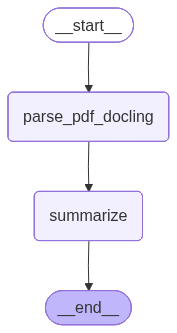

In [11]:
# Строим граф: два узла, линейная цепочка
graph = StateGraph(GraphState)
graph.add_node("parse_pdf_docling", parse_pdf_docling)
graph.add_node("summarize", summarize_step1)

graph.add_edge(START, "parse_pdf_docling")
graph.add_edge("parse_pdf_docling", "summarize")
graph.add_edge("summarize", END)

app_step1 = graph.compile()
Image(app_step1.get_graph().draw_mermaid_png())

In [12]:
state = GraphState(pdf_path="input/1. Gartner_Top 10 Strategic Technology Trends_2026.pdf")
result1 = app_step1.invoke(state)

In [13]:
print("[bold]--- Суммаризация (Шаг 1) ---[/bold]")
print(result1["summary"])

--- Суммаризация (Шаг 1) ---

Документ представляет собой отчет о стратегических технологических трендах на 2026 год от компании Gartner. В нем 
выделены три ключевые темы, определяющие будущее развитие технологий и их влияние на бизнес:

1. **Архитектор**: создание безопасных цифровых основ с использованием платформ разработки на основе искусственного
интеллекта (ИИ), суперкомпьютеров для ИИ и конфиденциального вычисления.
   
2. **Синтезатор**: интеграция специализированных моделей и систем искусственного интеллекта для создания адаптивных
экосистем, включая мультиагентные системы, языковые модели для конкретных областей и физический искусственный 
интеллект.

3. **Авангард**: повышение доверия через упреждающую кибербезопасность, цифровую аутентичность данных, платформы 
безопасности для ИИ и геопатризацию — перенос критических рабочих нагрузок в местные или суверенные облачные среды.

Отчет содержит подробные рекомендации по внедрению этих тенденций и созданию устойчивых конкурентных преимуществ за
счет цифровой трансформации. Он также предлагает шаблоны стратегического планирования и инструменты оценки решений 
для ИТ-лидеров.

---

# Шаг 2. Структурированный промпт: задаём требования к содержанию

Архитектура графа не меняется — только системный промпт. Это позволяет честно оценить вклад именно **промпт-инжиниринга**.

**Обратите внимание:**
- Тот же граф, то же состояние — другие инструкции
- Явные структурные требования (тема, технологии, планы действий) **заставляют** модель охватить все ключевые темы
- Это самый дешёвый способ улучшить качество — без изменения кода

**Что меняется:** только промпт. Граф и `GraphState` идентичны шагу 1.

In [14]:
show_prompt(STEP2_SUMMARY_PROMPT, title="Промпт шага 2")


def summarize_step2(state: GraphState) -> Dict[str, Any]:
    messages = [
        SystemMessage(content=STEP2_SUMMARY_PROMPT),
        HumanMessage(content=state["doc_markdown"]),
    ]
    result = llm.invoke(messages)
    return {"summary": result.content}

╭───────────────────────────────────────────────── Промпт шага 2 ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  Ты эксперт по технологическим трендам. Создай краткое, но информативное резюме отчёта на русском языке (5–7    │
│  предложений).                                                                                                  │
│                                                                                                                 │
│  Резюме обязательно должно отражать:                                                                            │
│  1. Общую тему и цель отчётад, укажи компанию, год.                                                             │
│  2. Опиши главные мысли и идеи.                                                                                 │
│  3. Перечисли упоминаемые тренды, технологии, концепции и другие значимые артефакты из отчёта, если они есть    │
│  (например: специализированные языковые модели, мультиагентные системы, конфиденциальные вычисления,            │
│  геопатриация данных).                                                                                          │
│  4. Упоминание практических планов, действий для руководителей.                                                 │
│  5. Подытожь основной посыл                                                                                     │
│                                                                                                                 │
│  Пиши связным текстом без маркированных списков. Объём: 5–10 предложений.                                       │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

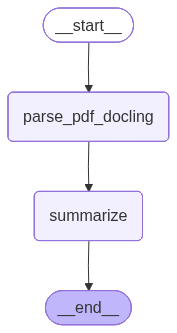

In [15]:
graph2 = StateGraph(GraphState)
graph2.add_node("parse_pdf_docling", parse_pdf_docling)
graph2.add_node("summarize", summarize_step2)

graph2.add_edge(START, "parse_pdf_docling")
graph2.add_edge("parse_pdf_docling", "summarize")
graph2.add_edge("summarize", END)

app_step2 = graph2.compile()
Image(app_step2.get_graph().draw_mermaid_png())

In [16]:
state2 = GraphState(pdf_path="input/1. Gartner_Top 10 Strategic Technology Trends_2026.pdf")
result2 = app_step2.invoke(state2)

In [17]:
print("[bold]--- Суммаризация (Шаг 2) ---[/bold]")
print(result2["summary"])

--- Суммаризация (Шаг 2) ---

В отчёте «Топ-10 стратегических технологических тенденций 2026 года» от компании Gartner рассматриваются ключевые 
направления развития технологий в условиях ускоряющегося темпа инноваций и рисков. Отчёт выделяет три темы, 
определяющие стратегию ведущих организаций: Архитектор — создание безопасных цифровых основ с использованием 
платформ разработки искусственного интеллекта (ИИ), суперкомпьютеров ИИ и конфиденциальных вычислений; Синтезатор —
интеграция специализированных моделей языка, многоагентных систем и физического ИИ для создания адаптивных 
экосистем; Вангард — повышение доверия через превентивную кибербезопасность, цифровое происхождение, платформы 
безопасности ИИ и геопатриацию данных.

Отчёт подчёркивает необходимость принятия решений руководителями высшего звена и предлагает конкретные действия для
реализации этих стратегий, включая пилотирование новых технологий, внедрение стандартов управления данными и 
разработку гибких архитектур инфраструктуры. Основной посыл заключается в том, что успешная трансформация бизнеса 
требует комплексного подхода к технологиям, который сочетает безопасность, масштабируемость и адаптируемость для 
достижения устойчивого роста и конкурентного преимущества в мире, управляемом искусственным интеллектом.

---

# Шаг 3. Добавляем извлечение метрик — второй навык агента

Агент получает вторую способность — **извлечение метрик**. Добавляем новое поле `report_md` в состояние и новый узел `extract_metrics`.

**Обратите внимание:**
- Расширяем `GraphState` новым полем — так агент «учится» новому навыку
- Граф остаётся линейным: парсинг → суммаризация → метрики (последовательно)
- Используем базовый промпт для метрик (`prompt_notebook_lm`), чтобы установить baseline
- Для метрик будем сравнивать результат с эталоном через CSV-таблицу

**Граф:**
```
parse_pdf_docling → summarize → extract_metrics → END
```

In [18]:
# Расширяем состояние: добавляем поле для результата извлечения метрик
class GraphState(TypedDict, total=False):
    pdf_path: str
    docling_doc: DoclingDocument
    doc_markdown: str
    summary: str
    report_md: str          # НОВОЕ: результат извлечения метрик

In [19]:
# Узел извлечения метрик с базовым промптом
def extract_metrics_basic(state: GraphState) -> Dict[str, Any]:
    message = [
        SystemMessage(content=prompt_notebook_lm),
        HumanMessage(content=state['doc_markdown']),
    ]
    result = llm.invoke(message)
    return {"report_md": result.content}

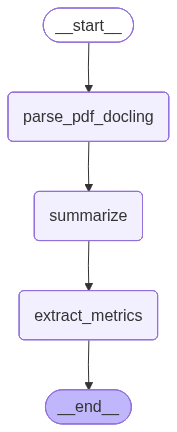

In [20]:
graph3 = StateGraph(GraphState)
graph3.add_node("parse_pdf_docling", parse_pdf_docling)
graph3.add_node("summarize", summarize_step2)
graph3.add_node("extract_metrics", extract_metrics_basic)

graph3.add_edge(START, "parse_pdf_docling")
graph3.add_edge("parse_pdf_docling", "summarize")
graph3.add_edge("summarize", "extract_metrics")
graph3.add_edge("extract_metrics", END)

app_step3 = graph3.compile()
Image(app_step3.get_graph().draw_mermaid_png())

In [21]:
state3 = GraphState(pdf_path="input/1. Gartner_Top 10 Strategic Technology Trends_2026.pdf")
result3 = app_step3.invoke(state3)

In [22]:
print("[bold]--- Суммаризация (Шаг 3) ---[/bold]")
print(result3["summary"])
print()
print("[bold]--- Метрики (Шаг 3) ---[/bold]")
print(result3["report_md"])

--- Суммаризация (Шаг 3) ---

Отчёт "Топ-10 стратегических технологических тенденций 2026 года" от компании Gartner представляет собой 
руководство для лидеров технологий в эпоху стремительных изменений, инноваций и рисков. В отчёте подчеркивается 
необходимость перехода к архитектуре, синтезу и защите доверия как ключевых тем, определяющих стратегию компаний в 
будущем.

Основные тенденции включают:

- **Архитектура**: создание безопасных, масштабируемых и адаптивных цифровых основ с использованием платформ 
разработки на основе искусственного интеллекта (ИИ), суперкомпьютеров ИИ и конфиденциальных вычислений.
- **Синтезист**: интеграция специализированных моделей языка, многоагентных систем и физического ИИ для создания 
инновационных решений.
- **Вангардец**: повышение уровня доверия через превентивную кибербезопасность, цифровое происхождение, платформы 
безопасности ИИ и геопатриацию данных.

Для практического применения отчет предлагает конкретные шаги и планы действий для каждого направления, включая 
пилотирование новых технологий, внедрение стандартов совместимости и подготовку команд к изменениям. Основной посыл
отчета заключается в том, что успешная трансформация требует не только технологического обновления, но и 
стратегической переориентации руководства, направленной на ускорение инноваций, укрепление устойчивости и защиту 
репутации организации.

--- Метрики (Шаг 3) ---

В представленном тексте нет явных числовых или других измеримых показателей ("метрик"), которые можно было бы четко
классифицировать на основе предложенных вами категорий. Вместо этого текст содержит описание стратегий, технологий 
и действий, направленных на развитие бизнеса и защиту данных в эпоху искусственного интеллекта и 
гиперподключенности. Однако можно выделить несколько ключевых тем и направлений для возможного анализа, если 
рассматривать их как потенциальные области измерения эффективности.

### Возможная классификация по категориям:

#### **Связанные с технологиями и платформами**
- Использование AI Native Development Platforms 
- Внедрение AI Supercomputing Platforms
- Применение Confidential Computing
- Развертывание Multiagent Systems
- Внедрение Domain-Specific Language Models
- Интеграция Physical AI

**Примеры возможных метрик**:  
- Количество успешно реализованных проектов с использованием AI native development platforms  
- Уровень использования вычислительных мощностей AI суперкомпьютеров  
- Уровни защиты конфиденциальной информации при использовании конфиденциального вычисления  
- Эффективность работы мультиагентных систем в реальных условиях  
- Качество моделей специализированных языков программирования  
- Производительность физической реализации ИИ-систем

---

#### **Связанные с безопасностью и доверием**
- Предупреждающая кибербезопасность (Preemptive Cybersecurity)
- Цифровая прослеживаемость (Digital Provenance)
- Платформы безопасности ИИ (AI Security Platforms)
- Геопатриация (Geopatriation)

**Примеры возможных метрик**:  
- Сокращение времени реагирования на угрозы благодаря предупреждающей кибербезопасности  
- Процент защищённых активов через цифровую прослеживаемость  
- Снижение рисков утечек данных с помощью платформ безопасности ИИ  
- Скорость миграции критических рабочих нагрузок в соответствии со стратегией геопатриации

---

#### **Связанные с управлением и стратегическим планированием**
- Определение стратегии AI First  
- Создание команд платформы и внедрение стандартов безопасности  
- Пилотирование новых решений и мониторинг результатов  
- Формулирование планов внедрения и развития цифровых основ

**Примеры возможных метрик**:  
- Время принятия стратегических решений относительно цифровой трансформации  
- Степень интеграции инновационных подходов в повседневные процессы компании  
- Показатели успеха пилотных проектов  
- Рост уровня осведомленности сотрудников о современных технологиях и подходах к управлению рисками

---

Таким образом, хотя документ не содержит конкретных чисел или явно выраженных метрик, он предоставляет достаточно 
контекста для того, чтобы разработать систему оценки эффективности внедрений и мероприятий, связанных с указанными 
выше категориями.

In [23]:
# Сравнение метрик с эталоном
df = pd.read_csv("input/step_1.csv")
print(f'Количество совпадений: {len(df[df["Есть ли метрика в отчете Гига"].str.contains("Да")])}')
df

Количество совпадений: 0

,Категория в NotebookLM,Метрики из NotebookLM,Есть ли метрика в отчете Гига,Метрики из отчета Гига
0,Связанные с киберугрозами и атаками,Количество задокументированных уязвимостей пре...,Нет,'-
1,Связанные с киберугрозами и атаками,80% несанкционированных транзакций ИИ будут св...,Нет,'-
2,Связанные с защитой киберпериметра и безопасно...,К 2030 году 50% всех расходов на защитное ПО б...,Нет,'-
3,Связанные с защитой киберпериметра и безопасно...,К 2029 году 75% процессов обработки данных в н...,Нет,'-
4,Связанные с защитой киберпериметра и безопасно...,Более 50% предприятий внедрят специализированн...,Нет,'-
5,Связанные с защитой киберпериметра и безопасно...,К 2029 году технологические продукты без упреж...,Нет,'-
6,Связанные с системами и инфраструктурой,40% предприятий перейдут на гибридные вычислит...,Нет,'-
7,Связанные с системами и инфраструктурой,К 2028 году более 20 поставщиков предложат уни...,Нет,'-
8,Связанные с системами и инфраструктурой,К 2030 году 75% предприятий перенесут рабочие ...,Нет,'-
9,Связанные с системами и инфраструктурой,К 2028 году 30% рабочих нагрузок GenAI будут и...,Нет,'-


---

# Шаг 4. Улучшенный промпт для метрик

Та же архитектура, но улучшенный промпт для метрик. Применяем тот же урок, что и на шагах 1→2: **промпт-инжиниринг** кардинально улучшает качество без изменения графа.

**Обратите внимание:**
- Новый промпт задаёт роль аналитика кибербезопасности
- Требует обязательные числовые значения у метрик
- Определяет структурированный формат вывода с примером
- Суммаризация не меняется — изолируем вклад именно промпта метрик
- Используем **фабричную функцию** `make_extract_metrics` для создания узла с фиксированным промптом

**Граф:** тот же, что в шаге 3.

In [24]:
show_prompt(new_prompt, title="Улучшенный промпт метрик (Шаг 4)")

╭─────────────────────────────────────── Улучшенный промпт метрик (Шаг 4) ────────────────────────────────────────╮
│                                                                                                                 │
│  Ты специалист по кибербезопасности, который занимается профессиональной публицистикой и глубоким анализом      │
│  аналитических отчетов в сфере кибербезопасности.                                                               │
│  Проанализируй документ ниже и найди метрики (временные, количественные, качественные).                         │
│  Метрики могут быть либо явно указаны в тексте документа, либо сформулированы тобой исходя описания возможных   │
│  изменений (рост, снижение, изменение интенсивности чего-либо и т.д.).                                          │
│  Метрики ОБЯЗАТЕЛЬНО должны выражаться какими-то числовыми значениями. Если есть какое-то описание метрики, но  │
│  нет цифрового выражения, то эту метрику описывать не нужно.                                                    │
│  Для каждой метрики необходимо указать краткое емкое название и описание, что именно метрика показывает         │
│  (исходное в тексте либо сформулированное тобой) в описании обязательно должно быть цифровое выражение этой     │
│  метрики.                                                                                                       │
│  Обрати внимание, что метрики могут быть временные, количественные, качественные. Необходимо найти и описать    │
│  ВСЕ метрики, упомянутые в документе. В случае отсутствия метрик укажи "Отчет не содержит метрик". Если         │
│  метрики найдены, сгруппируй по призканам. Примеры признаков:                                                   │
│      связанные с кибер атаками                                                                                  │
│      связанные с защитой кибер периметра                                                                        │
│      связанные с сетью                                                                                          │
│      связанные с системами                                                                                      │
│      связанные с бизнес процессами.                                                                             │
│  Не обязательно придерживаться именно такой классификации. Используй ее как отправную точку и пример. Если      │
│  поймешь, что метрики группируются по другим признакам, то можешь добавить новые признаки.                      │
│  Формат вывода: нумерованный список групп метрик. В каждой групп ненумерованный список метрик, входящих в эту   │
│  группу.                                                                                                        │
│  Формат вывода метрик: "Название метрики: Описание метрики вместе с числовыми показателями".                    │
│  Пример:                                                                                                        │
│  "1. Метрики, связанные с киберугрозами и атаками                                                               │
│      - Количество уязвимостей: Ожидается, что число задокументированных уязвимостей превысит 100 ежегодно к     │
│  2028 году.                                                                                                     │
│      - Природа угроз ИИ: 90% несанкционированных транзакций ИИ будут связаны с нарушениями политик              │
│  безопасности, а не с внешними атаками."                                                                        │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

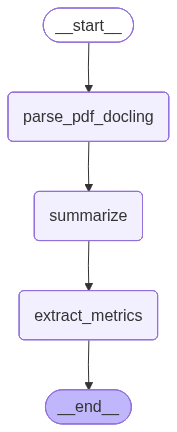

In [25]:
extract_metrics_improved = make_extract_metrics(new_prompt)

graph4 = StateGraph(GraphState)
graph4.add_node("parse_pdf_docling", parse_pdf_docling)
graph4.add_node("summarize", summarize_step2)
graph4.add_node("extract_metrics", extract_metrics_improved)

graph4.add_edge(START, "parse_pdf_docling")
graph4.add_edge("parse_pdf_docling", "summarize")
graph4.add_edge("summarize", "extract_metrics")
graph4.add_edge("extract_metrics", END)

app_step4 = graph4.compile()
Image(app_step4.get_graph().draw_mermaid_png())

In [26]:
state4 = GraphState(pdf_path="input/1. Gartner_Top 10 Strategic Technology Trends_2026.pdf")
result4 = app_step4.invoke(state4)

In [27]:
print("[bold]--- Суммаризация (Шаг 4) ---[/bold]")
print(result4["summary"])
print()
print("[bold]--- Метрики (Шаг 4) ---[/bold]")
print(result4["report_md"])

--- Суммаризация (Шаг 4) ---

В отчёте "Top 10 Strategic Technology Trends for 2026" от компании Gartner за 2026 год представлены стратегические 
направления технологий, которые станут катализаторами трансформации бизнеса в условиях искусственного интеллекта и 
гиперподключённого мира. Отчёт выделяет три ключевые темы инноваций: создание безопасных цифровых основ 
("Архитект"), синтезирование различных технологий для создания новых источников ценности ("Синтезист") и повышение 
доверия через безопасность и управление рисками ("Авангард").

Ключевые тренды включают:

- Платформы разработки с поддержкой ИИ;
- Суперкомпьютеры для задач искусственного интеллекта;
- Конфиденциальные вычисления;
- Мультиагентные системы;
- Специализированные языковые модели;
- Физический искусственный интеллект;
- Предупреждающая кибербезопасность;
- Цифровое происхождение;
- Площадки безопасности для искусственного интеллекта;
- Геопатриотизация данных.

Для руководителей предлагаются конкретные действия по внедрению этих тенденций, такие как пилотирование платформ 
разработки с использованием ИИ, внедрение суперкомпьютерных решений, использование доверенных вычислительных сред, 
а также развитие многоагентных систем и специализированных моделей языка.

Основной посыл отчета заключается в том, что успешная трансформация требует не только внедрения отдельных 
технологий, но и интеграции их в общую стратегию предприятия, обеспечивая при этом доверие, безопасность и 
устойчивость к изменениям.

--- Метрики (Шаг 4) ---

1. Метрики, связанные с технологиями искусственного интеллекта
    - Процент предприятий, использующих гибридные вычислительные архитектуры: К 2028 году ожидается, что 40% 
предприятий перейдут на использование гибридных архитектур вычислений (по сравнению с текущими 8%).
    - Число поставщиков платформ для разработчиков, использующие суперкомпьютерные среды: Более 20 поставщиков 
предложат унифицированные платформы разработки, поддерживающие суперкомпьютинговые среды до 2028 года.
    - Рост запросов на системы многоагентного взаимодействия: Отмечается рост числа запросов от клиентов о системах
многоагентного взаимодействия на 1445% за период с первого квартала 2024 года по второй квартал 2025 года.
    - Доля ведущих производителей решений на базе физического искусственного интеллекта: К 2028 году пять из десяти
крупнейших компаний-производителей систем искусственного интеллекта предложат продукты на основе физической 
реализации искусственного интеллекта.

2. Метрики, связанные с безопасностью информационных технологий
    - Потеря актуальности продуктов без превентивной кибербезопасности: К 2029 году технология или продукт, не 
обеспечивающий превентивную защиту от кибератак, потеряет свою рыночную значимость.

3. Метрики, связанные с разработкой программного обеспечения
    - Производительность команд при использовании платформ разработки на основе искусственного интеллекта: Пять 
небольших команд смогут одновременно разрабатывать пять приложений благодаря использованию инструментов на основе 
искусственного интеллекта, позволяющих ускорить разработку программных продуктов.

4. Метрики, связанные с управлением данными и их защищенностью
    - Уровень защиты данных во время обработки: Использование конфиденциальных вычислений позволяет защитить данные
даже в облачных средах, обеспечивая соответствие требованиям конфиденциальности и локализации данных.

Отчет не содержит других явных метрик.

In [28]:
# Сравнение метрик с эталоном
df = pd.read_csv("input/step_2.csv")
print(f'Количество совпадений: {len(df[df["Есть ли метрика в отчете Гига"].str.contains("Да")])}')
df

Количество совпадений: 5

,Категория в NotebookLM,Метрики из NotebookLM,Есть ли метрика в отчете Гига,Метрики из отчета Гига
0,Связанные с киберугрозами и атаками,Количество задокументированных уязвимостей пре...,Нет,'-
1,Связанные с киберугрозами и атаками,80% несанкционированных транзакций ИИ будут св...,Нет,'-
2,Связанные с защитой киберпериметра и безопасно...,К 2030 году 50% всех расходов на защитное ПО б...,Нет,'-
3,Связанные с защитой киберпериметра и безопасно...,К 2029 году 75% процессов обработки данных в н...,Нет,Уровень защиты данных во время обработки: испо...
4,Связанные с защитой киберпериметра и безопасно...,Более 50% предприятий внедрят специализированн...,Нет,'-
5,Связанные с защитой киберпериметра и безопасно...,К 2029 году технологические продукты без упреж...,Да,"К 2029 году технология или продукт, не обеспеч..."
6,Связанные с системами и инфраструктурой,40% предприятий перейдут на гибридные вычислит...,Да,"К 2028 году ожидается, что 40% предприятий пер..."
7,Связанные с системами и инфраструктурой,К 2028 году более 20 поставщиков предложат уни...,Да,Более 20 поставщиков предложат унифицированные...
8,Связанные с системами и инфраструктурой,К 2030 году 75% предприятий перенесут рабочие ...,Нет,'-
9,Связанные с системами и инфраструктурой,К 2028 году 30% рабочих нагрузок GenAI будут и...,Нет,'-


---

# Шаг 5. Map-Reduce: постраничное извлечение метрик + параллельная суммаризация

Главное архитектурное изменение: вводим паттерн **Map-Reduce** для извлечения метрик. Каждая страница обрабатывается независимо и параллельно (map), затем результаты объединяются (reduce). Это решает проблему **«lost-in-the-middle»** для длинных документов.

Суммаризация остаётся единым вызовом LLM на весь документ — и запускается **параллельно** с постраничной обработкой метрик.

**Обратите внимание:**
- `Send` — динамический fan-out: создаёт по одному экземпляру узла на каждую страницу
- `Annotated[List[...], operator.add]` — автоматический reducer для сбора результатов параллельных узлов
- При `max_concurrency=4` суммаризация занимает 1 слот кратковременно, а постраничные воркеры используют оставшиеся 3 (затем все 4 после завершения суммаризации)
- LangGraph автоматически ждёт завершения **всех** рёбер в END

**Граф:**
```
parse_pdf_docling ─┬→ summarize ──────────────────────────────────────────→ END
                   └→ prepare_pages → [fanout] → extract_metrics_page × N → reduce_reports → END
```

In [29]:
# Расширяем состояние: добавляем поля для map-reduce
class GraphState(TypedDict, total=False):
    pdf_path: str
    doc_id: str
    docling_doc: DoclingDocument
    doc_markdown: str
    summary: str
    # map-reduce поля:
    pages: List[Dict[str, Any]]                                    # [{page_no: int, md: str}, ...]
    page_metrics: Annotated[List[Dict[str, Any]], operator.add]    # reducer: автоматически накапливает
    report_md: str

In [30]:
def prepare_pages(state: GraphState) -> Dict[str, Any]:
    # Разбиваем документ в md формате на страницы по маркеру <!-- PAGE_BREAK -->
    pages_md = [{"page_no": i, "md": x.strip()}
                for i, x in enumerate(state["doc_markdown"].split("<!-- PAGE_BREAK -->"))
                if x.strip()]
    return {"pages": pages_md, "page_metrics": []}


def fanout_pages(state: GraphState):
    # На каждую страницу создаём отдельный запуск узла-воркера — распараллеливаем процесс
    return [
        Send("extract_metrics_page", {"page": page})
        for page in state["pages"]
    ]


def extract_metrics_page(state: Dict[str, Any]) -> Dict[str, Any]:
    """Извлекаем метрики для одной страницы. Запускается параллельно для всех страниц."""
    page = state["page"]
    messages = [
        SystemMessage(content=new_prompt),
        HumanMessage(content=f'Документ:\n{page["md"]}'),
    ]
    result = llm.invoke(messages)
    return {
        "page_metrics": [{"page_no": page["page_no"], "summary": result.content}]
    }


def reduce_reports(state: GraphState) -> Dict[str, Any]:
    """Объединяем результаты работы LLM по всем страницам в один отчет."""
    items = state.get("page_metrics", [])
    # Сортируем по page_no, потому что параллельные апдейты могут прийти в разном порядке
    items = sorted(items, key=lambda x: (x.get("page_no") is None, x.get("page_no")))
    combined = "\n\n".join(
        i['summary'] for i in items if 'Отчет не содержит' not in i["summary"]
    )
    return {"report_md": combined}

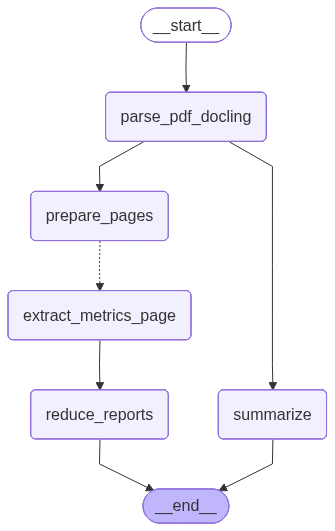

In [31]:
graph5 = StateGraph(GraphState)
graph5.add_node("parse_pdf_docling", parse_pdf_docling)
graph5.add_node("summarize", summarize_step2)
graph5.add_node("prepare_pages", prepare_pages)
graph5.add_node("extract_metrics_page", extract_metrics_page)
graph5.add_node("reduce_reports", reduce_reports)

graph5.add_edge(START, "parse_pdf_docling")
# После парсинга — две параллельные ветки
graph5.add_edge("parse_pdf_docling", "summarize")
graph5.add_edge("parse_pdf_docling", "prepare_pages")
# map step: динамический fan-out
graph5.add_conditional_edges("prepare_pages", fanout_pages, ["extract_metrics_page"])
# reduce step: fan-in в один узел
graph5.add_edge("extract_metrics_page", "reduce_reports")
# Обе ветки сходятся в END
graph5.add_edge("summarize", END)
graph5.add_edge("reduce_reports", END)

app_step5 = graph5.compile()
Image(app_step5.get_graph().draw_mermaid_png())

In [33]:
state5 = GraphState(pdf_path="input/1. Gartner_Top 10 Strategic Technology Trends_2026.pdf")
config5 = {"max_concurrency": 3}
result5 = app_step5.invoke(state5, config5)

In [34]:
print("[bold]--- Суммаризация (Шаг 5) ---[/bold]")
print(result5["summary"])
print()
print("[bold]--- Метрики (Шаг 5) ---[/bold]")
print(result5["report_md"])

--- Суммаризация (Шаг 5) ---

В отчёте «Топ 10 стратегических технологических тенденций 2026 года» от компании Gartner представлены ключевые 
направления развития технологий, которые помогут организациям адаптироваться к ускоряющимся изменениям в мире 
искусственного интеллекта и гиперподключённости. Отчёт подчёркивает необходимость стратегического подхода со 
стороны высшего руководства компаний.

Основные темы включают архитектуру цифровых основ с использованием платформ разработки на основе ИИ, 
суперкомпьютеров для задач ИИ и конфиденциальных вычислений; синтезирование различных технологий — многоагентные 
системы, специализированные языковые модели и физический искусственный интеллект; а также повышение доверия через 
превентивную кибербезопасность, цифровое происхождение, платформы безопасности ИИ и геопатриотизацию данных.

Для руководителей предлагаются конкретные шаги и планы действий по внедрению этих технологий, включая оценку 
критических рабочих нагрузок, пилотирование новых решений, внедрение стандартов управления безопасностью и 
подготовку сотрудников. Основной посыл отчета заключается в том, что успешная трансформация требует комплексного 
подхода, сочетающего инновации, безопасность и доверие.

--- Метрики (Шаг 5) ---

1. Метрики, связанные с технологиями искусственного интеллекта и суперкомпьютинга
    - Процент предприятий, использующих гибридные вычислительные архитектуры: К 2028 году ожидается рост до 40%, 
тогда как на текущий момент этот показатель составляет всего 8%.
    - Число поставщиков платформ для разработчиков, поддерживающих суперкомпьютерные среды: К 2028 году количество 
таких компаний достигнет более чем 20+.

1. Метрики, связанные с технологиями искусственного интеллекта
    - Рост запросов на системы с несколькими агентами: Отмечается рост на 1,445% от первого квартала 2024 года до 
второго квартала 2025 года.

1. Метрики, связанные с развитием рынка физического искусственного интеллекта  
   - Доля ведущих поставщиков физических решений на основе ИИ: К 2028 году пять из десяти крупнейших поставщиков 
технологий ИИ предложат продукты для физического применения ИИ.

In [35]:
# Сравнение метрик с эталоном
df = pd.read_csv("input/step_3.csv")
print(f'Количество совпадений: {len(df[df["Есть ли метрика в отчете Гига"].str.contains("Да")])}')
df

Количество совпадений: 3

,Категория в NotebookLM,Метрики из NotebookLM,Есть ли метрика в отчете Гига,Метрики из отчета Гига
0,Связанные с киберугрозами и атаками,Количество задокументированных уязвимостей пре...,Нет,'-
1,Связанные с киберугрозами и атаками,80% несанкционированных транзакций ИИ будут св...,Нет,'-
2,Связанные с защитой киберпериметра и безопасно...,К 2030 году 50% всех расходов на защитное ПО б...,Нет,'-
3,Связанные с защитой киберпериметра и безопасно...,К 2029 году 75% процессов обработки данных в н...,Нет,'-
4,Связанные с защитой киберпериметра и безопасно...,Более 50% предприятий внедрят специализированн...,Нет,'-
5,Связанные с защитой киберпериметра и безопасно...,К 2029 году технологические продукты без упреж...,Нет,'-
6,Связанные с системами и инфраструктурой,40% предприятий перейдут на гибридные вычислит...,Да,"Процент предприятий, использующих гибридные вы..."
7,Связанные с системами и инфраструктурой,К 2028 году более 20 поставщиков предложат уни...,Да,Число поставщиков платформ для разработчиков в...
8,Связанные с системами и инфраструктурой,К 2030 году 75% предприятий перенесут рабочие ...,Нет,'-
9,Связанные с системами и инфраструктурой,К 2028 году 30% рабочих нагрузок GenAI будут и...,Нет,'-


---

# Шаг 6. Добавляем парсинг изображений

Меняем только **один узел**: парсер PDF теперь анализирует изображения через GigaChat. Диаграммы, схемы и графики, которые Docling заменял на `<!-- image -->`, теперь описываются текстом и вставляются в markdown.

**Обратите внимание:**
- Обогащённый текст попадает **и** в суммаризацию, **и** в извлечение метрик
- Архитектура графа идентична шагу 5 — изолируем вклад именно анализа изображений
- `make_parse_pdf_gigachat_postprocess` — фабричная функция: парсит PDF, для каждого `<!-- image -->` вызывает GigaChat, заменяет плейсхолдер описанием (строго 1:1)
- Шаг работает значительно **дольше** из-за вызовов GigaChat для каждого изображения

**Граф:** тот же, что в шаге 5, но узел парсинга заменён на image-aware версию.

In [36]:
# Фабрика возвращает функцию-узел с зафиксированным промптом для анализа изображений
parse_with_gigachat_images = make_parse_pdf_gigachat_postprocess(prompt=IMAGE_ANALYSIS_PROMPT)

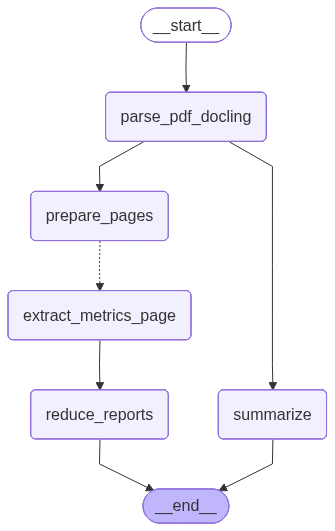

In [37]:
# Граф идентичен шагу 5 — единственное отличие: узел парсинга заменён на image-aware версию
graph6 = StateGraph(GraphState)
graph6.add_node("parse_pdf_docling", parse_with_gigachat_images)  # ← единственное отличие от шага 5
graph6.add_node("summarize", summarize_step2)
graph6.add_node("prepare_pages", prepare_pages)
graph6.add_node("extract_metrics_page", extract_metrics_page)
graph6.add_node("reduce_reports", reduce_reports)

graph6.add_edge(START, "parse_pdf_docling")
graph6.add_edge("parse_pdf_docling", "summarize")
graph6.add_edge("parse_pdf_docling", "prepare_pages")
graph6.add_conditional_edges("prepare_pages", fanout_pages, ["extract_metrics_page"])
graph6.add_edge("extract_metrics_page", "reduce_reports")
graph6.add_edge("summarize", END)
graph6.add_edge("reduce_reports", END)

app_step6 = graph6.compile()
Image(app_step6.get_graph().draw_mermaid_png())

In [39]:
state6 = GraphState(pdf_path="input/1. Gartner_Top 10 Strategic Technology Trends_2026.pdf")
config6 = {"max_concurrency": 3}
result6 = app_step6.invoke(state6, config6)

In [40]:
print("[bold]--- Суммаризация (Шаг 6) ---[/bold]")
print(result6["summary"])
print()
print("[bold]--- Метрики (Шаг 6) ---[/bold]")
print(result6["report_md"])

--- Суммаризация (Шаг 6) ---

Компания Gartner представила отчет за 2026 год, выделив десять стратегических технологических трендов, определяющих
путь к цифровой трансформации бизнеса в условиях роста рисков и ускорения инноваций. Отчет фокусируется на трех 
основных направлениях: создание надежной инфраструктуры («Архитект»), интеграция специализированных технологий 
(«Синтезатор») и повышение доверия и безопасности («Авангард»).

Ключевые тренды включают:

- Платформы разработки на базе искусственного интеллекта (AI-native development platforms);
- Суперкомпьютерные платформы для ИИ (AI supercomputing platforms);
- Конфиденциальные вычисления (confidential computing);
- Мультиагентные системы (multiagent systems);
- Специализированные языковые модели (domain-specific language models);
- Физический искусственный интеллект (physical AI);
- Предупреждающая кибербезопасность (preemptive cybersecurity);
- Цифровое происхождение (digital provenance);
- Платформы безопасности для ИИ (AI security platforms);
- Геопатризация данных (geopatriation).

Руководителям рекомендуется разработать стратегии адаптации этих тенденций, включая внедрение новых подходов к 
разработке, укреплению кибербезопасности и управлению рисками. Основной посыл отчета заключается в том, что 
успешные организации должны активно интегрировать эти тренды в свои планы, чтобы обеспечить устойчивый рост и 
конкурентные преимущества в будущем.

--- Метрики (Шаг 6) ---

1. Метрики, связанные с безопасностью данных и конфиденциальными вычислениями
    - Доля обработанных данных под защитой конфиденциальных вычислений: К 2029 году ожидается, что 75% всех данных,
обрабатываемых в доверенных инфраструктурах, будут защищены конфиденциальными вычислениями.

1. Метрики, связанные с развитием технологий мультиагентных систем
    - Рост запросов на использование мультиагентных систем: Отмечается рост на 1,445% от первого квартала 2024 года
до второго квартала 2025 года.
    - Доля использования специализированных агентов в мультиагентных системах: Ожидается увеличение до 70% к 2027 
году.
    - Уровень поддержки многоплатформенной интероперабельности в мультиагентных системах: Прогнозируется достижение
уровня 60% к 2028 году.

1. Метрики, связанные с развитием технологий физического ИИ
    - Доля поставщиков физических решений ИИ среди топовых компаний: К 2028 году пять из десяти ведущих поставщиков
систем искусственного интеллекта предложат продукты физического ИИ.
    - Уровень внедрения роботизированной техники и автоматизации на складах: К 2028 году ожидается использование 
роботизации и автоматизации на 80% всех складов.

1. Метрики, связанные с внедрением технологий защиты на базе ИИ
   - Доля компаний, использующих ИИ для обеспечения безопасности: +50% предприятий примут ИИ в качестве основного 
средства безопасности к 2028 году.
   
2. Метрики, связанные с киберугрозами и атаками
   - Природа угроз ИИ: 80% несанкционированных транзакций с использованием ИИ будут происходить из-за внутренних 
нарушений, а не внешних атак.

1. Метрики, связанные с изменениями в использовании облачных сервисов:
    - Процент предприятий, которые переместят рабочие нагрузки для снижения геополитического риска: К 2030 году 
ожидается, что 75% компаний переориентируют свои рабочие нагрузки из-за геополитических рисков.

2. Метрики, связанные с расширением предложений облачных услуг:
    - Темпы расширения суверенных облачных предложений от крупных провайдеров и локальных поставщиков: Отмечается 
быстрое расширение суверенных облачных предложений крупными поставщиками облачных услуг и местными провайдерами без
конкретных цифровых данных о темпах роста или охвате рынка.

(Примечание: вторая группа включает только упоминание быстрого темпа расширения, однако конкретная цифровая оценка 
отсутствует.)  
Отчет содержит одну явную метрику и одно указание на изменения без четкого цифрового представления.

1. Метрики, связанные с оценкой поставщиков технологий
    - Общий балл оценки поставщика: Показатель варьируется от 0 до 100 баллов; например, один из поставщиков 
получил общий балл 95/100.
    - Баллы функциональных требований: Оцениваются функциональные возможности решения поставщиком, диапазон также 
составляет от 0 до 100 баллов; конкретный поставщик имеет оценку функциональности — 79 баллов.
    - Технические требования: Отражают соответствие техническим требованиям заказчика, оценивается аналогично 
предыдущему пункту; конкретная оценка технического соответствия одного из поставщиков равна 91 баллу.
    - Поддержка и услуги: Определяют качество поддержки и дополнительных услуг, предоставляемых поставщиком, 
измеряется по шкале от 0 до 100; оценка данного параметра составила 64 балла.
    - Здоровье поставщика: Характеризует стабильность бизнеса поставщика, максимальный показатель равен 100, 
текущая оценка — 90 баллов.
    - Ценообразование и коммерческие условия: Учитывает стоимость решений и коммерческих условий, максимальное 
значение равно 100, текущий результат — 79 баллов.

2. Метрики, связанные с процессом выбора поставщика
    - Процент завершения процесса оценки: Например, одна из компаний завершила процесс оценки на уровне 95%, другая
— на уровне 88%.
    - Стадии выполнения этапов оценки: Включает категории «завершено», «в процессе» или «не начато». Например, 
некоторые этапы отмечены как завершенные («Overall Score»), другие находятся в стадии разработки («In Progress»).

In [41]:
# Сравнение метрик с эталоном
df = pd.read_csv("input/step_4.csv")
print(f'Количество совпадений: {len(df[df["Есть ли метрика в отчете Гига"].str.contains("Да")])}')
df

Количество совпадений: 7

,Категория в NotebookLM,Метрики из NotebookLM,Есть ли метрика в отчете Гига,Метрики из отчета Гига
0,Связанные с киберугрозами и атаками,Количество задокументированных уязвимостей пре...,Нет,'-
1,Связанные с киберугрозами и атаками,80% несанкционированных транзакций ИИ будут св...,Да,80% несанкционированных транзакций с использов...
2,Связанные с защитой киберпериметра и безопасно...,К 2030 году 50% всех расходов на защитное ПО б...,Нет,'-
3,Связанные с защитой киберпериметра и безопасно...,К 2029 году 75% процессов обработки данных в н...,Да,"К 2029 году ожидается, что 75% всех данных, об..."
4,Связанные с защитой киберпериметра и безопасно...,Более 50% предприятий внедрят специализированн...,Нет,'-
5,Связанные с защитой киберпериметра и безопасно...,К 2029 году технологические продукты без упреж...,Нет,'-
6,Связанные с системами и инфраструктурой,40% предприятий перейдут на гибридные вычислит...,Нет,'-
7,Связанные с системами и инфраструктурой,К 2028 году более 20 поставщиков предложат уни...,Нет,'-
8,Связанные с системами и инфраструктурой,К 2030 году 75% предприятий перенесут рабочие ...,Да,"К 2030 году ожидается, что 75% компаний переор..."
9,Связанные с системами и инфраструктурой,К 2028 году 30% рабочих нагрузок GenAI будут и...,Нет,'-


---

# Шаг 7. Полный документ с изображениями — финальная архитектура

Возвращаемся к анализу документа **целиком** (без map-reduce), но сохраняем парсинг изображений. И суммаризация, и метрики видят полный документ с описаниями изображений — **максимальный контекст**.

**Обратите внимание:**
- Оба вызова — одиночные запросы к LLM, поэтому запускаем их **параллельно** от узла парсинга
- Это **продакшен-конфигурация**: лучшее качество (полный контекст + изображения) и эффективное параллельное выполнение
- Граф максимально простой — три узла, две параллельные ветки

**Граф:**
```
parse_pdf_docling ─┬→ summarize ──────→ END
                   └→ extract_metrics → END
```

In [42]:
# Упрощаем состояние: map-reduce поля больше не нужны
class GraphState(TypedDict, total=False):
    pdf_path: str
    docling_doc: DoclingDocument
    doc_markdown: str
    summary: str
    report_md: str

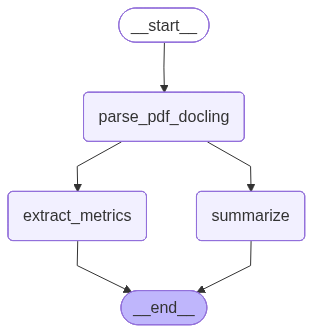

In [43]:
extract_metrics_node = make_extract_metrics(new_prompt)

graph7 = StateGraph(GraphState)
graph7.add_node("parse_pdf_docling", parse_with_gigachat_images)
graph7.add_node("summarize", summarize_step2)
graph7.add_node("extract_metrics", extract_metrics_node)

graph7.add_edge(START, "parse_pdf_docling")
# Две параллельные ветки от парсинга
graph7.add_edge("parse_pdf_docling", "summarize")
graph7.add_edge("parse_pdf_docling", "extract_metrics")
graph7.add_edge("summarize", END)
graph7.add_edge("extract_metrics", END)

app_step7 = graph7.compile()
Image(app_step7.get_graph().draw_mermaid_png())

In [44]:
state7 = GraphState(pdf_path="input/1. Gartner_Top 10 Strategic Technology Trends_2026.pdf")
config7 = {"max_concurrency": 4}
result7 = app_step7.invoke(state7, config7)

In [45]:
print("[bold]--- Суммаризация (Шаг 7) ---[/bold]")
print(result7["summary"])
print()
print("[bold]--- Метрики (Шаг 7) ---[/bold]")
print(result7["report_md"])

--- Суммаризация (Шаг 7) ---

Отчет Gartner за 2026 год посвящен стратегическим технологиям, определяющим развитие бизнеса в условиях роста 
влияния искусственного интеллекта и гиперподключенности мира. Отмечается необходимость комплексных мер со стороны 
руководства компаний для адаптации к новым условиям, основанным на трех основных направлениях: архитектура, синтез 
и авангард.

Основные тренды включают:

- Архитектура: создание адаптивных и масштабируемых цифровых основ с применением нативных платформ разработки на 
базе ИИ, супервычислительных платформ и конфиденциальных вычислений.
- Синтез: интеграция специализированных языковых моделей, многоагентных систем и физического ИИ для повышения 
эффективности процессов.
- Авангард: повышение доверия и устойчивости путем внедрения превентивной кибербезопасности, цифровой верификации 
происхождения данных и локализации критических информационных активов («геопатриации»).

Практически руководителям рекомендуется предпринять конкретные шаги по внедрению этих технологий: модернизировать 
инфраструктуру, обеспечить безопасность и защиту данных, развивать навыки сотрудников и создавать стратегии 
перехода к новому цифровому ландшафту.

Основной посыл отчета заключается в том, что успешное внедрение перечисленных тенденций позволит компаниям 
эффективно конкурировать и устойчиво развиваться в быстро меняющемся мире, управляемом искусственным интеллектом.

--- Метрики (Шаг 7) ---

1. Метрики, связанные с развитием технологии и бизнеса
    - Процент организаций, использующих tiny teams: Ожидается, что к 2030 году 80% организаций перейдут на 
небольшие команды разработки, усиленные искусственным интеллектом.
    - Доля портфеля приложений, построенных на AI-native платформах: Отмечается рост с 2% в 2025 году до ожидаемых 
40% к 2030 году.
    - Рост числа запросов по мультиагентным системам: Зафиксирован резкий рост в 1445% за период с 1 квартала 2024 
года по 2 квартал 2025 года.
    - Использование узкоспециализированных агентов в мультиагентных системах: Предполагается, что к 2027 году 70% 
таких систем будут применять специализированные агенты.
    - Поддержка многоплатформенной совместимости в мультиагентных системах: Ожидается, что к 2028 году эта 
поддержка достигнет 60%.
    - Предсказуемость расходов на безопасность программного обеспечения: По оценкам, к 2030 году половина бюджета 
пойдет на превентивную защиту.
    - Увеличение количества задокументированных уязвимостей: Ежегодное количество уязвимостей превысит отметку в 1 
млн к 2030 году.
    - Гибридные архитектуры: К 2028 году 40% компаний внедрят гибридные среды вычислений против текущих 8%.
    - Поставщики унифицированных платформ: Более 20 компаний предложат такие платформы к 2028 году.
    - Геопатризация: К 2030 году 75% предприятий перенесут критически важные рабочие нагрузки на суверенные облака 
или собственные инфраструктуры.

2. Метрики, связанные с кибербезопасностью
    - Роль превентивной кибербезопасности: К 2029 году продукты без таких функций потеряют актуальность на рынке.
    - Инновационная роль платформ безопасности на базе ИИ: К 2028 году более половины компаний выберут ИИ в 
качестве ключевого инструмента безопасности.
    - Уровень внутреннего нарушения: К 2030 году около 80% инцидентов с ИИ произойдут вследствие внутренних 
проблем, а не внешних воздействий.

3. Метрики, связанные с управлением технологиями и изменениями
    - Оценка рисков внедрения новых технологий: Организациям рекомендуется проводить регулярный аудит своих активов
и процессов для выявления потенциальных опасностей.
    - Соотношение собственных разработок и покупок готовых решений: Компании переходят от покупки готовых продуктов
к самостоятельному созданию необходимого функционала благодаря технологиям на базе ИИ.
    - Переход к гибридным архитектурам: Организации начинают активно осваивать смешанные подходы к обработке данных
и работе с приложениями.

4. Метрики, связанные с принятием решений и адаптацией к новым условиям
    - Распространенность физического ИИ: К 2028 году топ-10 поставщиков ИИ начнут предлагать физические системы.
    - Применение специализированных языковых моделей: К 2028 году свыше 60% корпоративного генеративного ИИ станет 
специализированным.
    - Локализация критичных рабочих нагрузок: К 2030 году большинство крупных компаний перенесёт свои критически 
важные процессы ближе к своим географическим регионам для снижения риска.

5. Метрики, связанные с результатами пилотных проектов и внедрений
    - Показатели эффективности и возврата инвестиций (ROI): Регулярная оценка результатов пилотных запусков 
необходима для подтверждения ценности внедряемых технологий.
    - Сокращение сроков доставки софта: Благодаря AI-native инструментам можно значительно ускорить разработку и 
внедрение нового ПО.
    - Повышение точности и надежности систем: Специализированные языковые модели позволяют снизить ошибки и 
повысить производительность труда сотрудников.

6. Метрики, связанные с повышением квалификации персонала
    - Масштаб обучения специалистов: Важна подготовка кадров для эффективного использования новых подходов и 
методов, включая работу с мультиагентными системами и физическим ИИ.
    - Оптимизация производительности команд: Современные технологии требуют переосмысления структуры команд и 
распределения ролей среди сотрудников.

Отчет содержит значительное количество метрик, связанных с технологическими трендами, кибербе

In [48]:
# Сравнение метрик с эталоном
df = pd.read_csv("input/step_5.csv")
print(f'Количество совпадений: {len(df[df["Есть ли метрика в отчете Гига"].str.contains("Да")])}')
df

Количество совпадений: 14

,Категория в NotebookLM,Метрики из NotebookLM,Есть ли метрика в отчете Гига,Метрики из отчета Гига
0,Связанные с киберугрозами и атаками,Количество задокументированных уязвимостей пре...,Да,Увеличение количества задокументированных уязв...
1,Связанные с киберугрозами и атаками,80% несанкционированных транзакций ИИ будут св...,Да,Уровень внутреннего нарушения: К 2030 году око...
2,Связанные с защитой киберпериметра и безопасно...,К 2030 году 50% всех расходов на защитное ПО б...,Да,Предсказуемость расходов на безопасность ПО: П...
3,Связанные с защитой киберпериметра и безопасно...,К 2029 году 75% процессов обработки данных в н...,Нет,'-
4,Связанные с защитой киберпериметра и безопасно...,Более 50% предприятий внедрят специализированн...,Да,Инновационная роль платформ безопасности на ба...
5,Связанные с защитой киберпериметра и безопасно...,К 2029 году технологические продукты без упреж...,Да,Роль превентивной кибербезопасности: К 2029 го...
6,Связанные с системами и инфраструктурой,40% предприятий перейдут на гибридные вычислит...,Да,Гибридные архитектуры: К 2028 году 40% компани...
7,Связанные с системами и инфраструктурой,К 2028 году более 20 поставщиков предложат уни...,Да,Поставщики унифицированных платформ: Более 20 ...
8,Связанные с системами и инфраструктурой,К 2030 году 75% предприятий перенесут рабочие ...,Да,Геопатризация: К 2030 году 75% предприятий пер...
9,Связанные с системами и инфраструктурой,К 2028 году 30% рабочих нагрузок GenAI будут и...,Нет,'-


---

# Итоги: эволюция агента

| Шаг | Суммаризация | Метрики | Парсер | Архитектура |
|-----|-------------|---------|--------|-------------|
| 1 | Базовый промпт | — | Docling | Линейный |
| 2 | Структурированный промпт | — | Docling | Линейный |
| 3 | Структурированный промпт | Базовый промпт | Docling | Линейный (послед.) |
| 4 | Структурированный промпт | Улучшенный промпт | Docling | Линейный (послед.) |
| 5 | Параллельно с метриками | Map-Reduce (парал.) | Docling | Fan-out + парал. ветки |
| 6 | Параллельно с метриками | Map-Reduce (парал.) | Docling + GigaChat images | Fan-out + парал. ветки |
| 7 | Параллельно с метриками | Полный документ (парал.) | Docling + GigaChat images | Парал. ветки |

## Ключевые уроки

**Шаги 1→2:** Промпт-инжиниринг — самый дешёвый способ улучшить качество. Явные требования к содержанию заставляют модель охватить нужные темы.

**Шаги 3→4:** Расширение агента новыми навыками — добавляем узлы и поля в состояние. Каждый навык — отдельный узел графа.

**Шаг 5:** Map-Reduce и параллелизация — решаем проблему «lostin-the-middle» для длинных документов. `Send` + `Annotated[List, operator.add]` — ключевые паттерны LangGraph.

**Шаг 6:** Мультимодальность — замена одного узла (парсера) обогащает данные для всех downstream-узлов.

**Шаг 7:** Упрощение — когда модель может обработать весь документ целиком, простая параллелизация двух задач эффективнее сложного map-reduce.

## Рекомендация для продакшена

| Тип документа | Рекомендуемый подход |
|---|---|
| Короткий текстовый (~10 стр.) | Шаг 4: структурированные промпты, один вызов LLM |
| Длинный текстовый (>15 стр.) | Шаг 5: map-reduce, быстро и эффективно |
| Насыщенный графиками/схемами | Шаг 7: полный документ + парсинг изображений |